In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
def onliner_matmul(a, b):
    return np.array([np.sum([a[i, k] * b[k, j] for k in range(a.shape[1])]) for i in range(a.shape[0]) for j in range(b.shape[1])]).reshape(a.shape[0], b.shape[1])

def naive_matmul(a, b):
    output = np.empty((a.shape[0], b.shape[1]), dtype = a.dtype)
    for i in range(a.shape[0]):
        for j in range(b.shape[1]):
            output[i, j] = np.sum([a[i, k] * b[k, j] for k in range(a.shape[1])])
    return output

In [4]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
b = np.array([[1, 0, 1], [0, 1, 0]])

print(a@b.T)
print(onliner_matmul(a, b.T))
print(naive_matmul(a, b.T))

[[ 4  2]
 [10  5]
 [16  8]]
[[ 4  2]
 [10  5]
 [16  8]]
[[ 4  2]
 [10  5]
 [16  8]]


In [5]:
def time_matmul(func, a, b):
    start = time.time()
    func(a, b)
    return time.time() - start

sizes = [10, 50, 100, 200, 500, 1000]
numpy_times = []
onliner_times = []
naive_times = []
for size in sizes:
    a = np.random.rand(size, size)
    b = np.random.rand(size, size)
    numpy_times.append(time_matmul(np.dot, a, b))
    onliner_times.append(time_matmul(onliner_matmul, a, b))
    naive_times.append(time_matmul(naive_matmul, a, b))

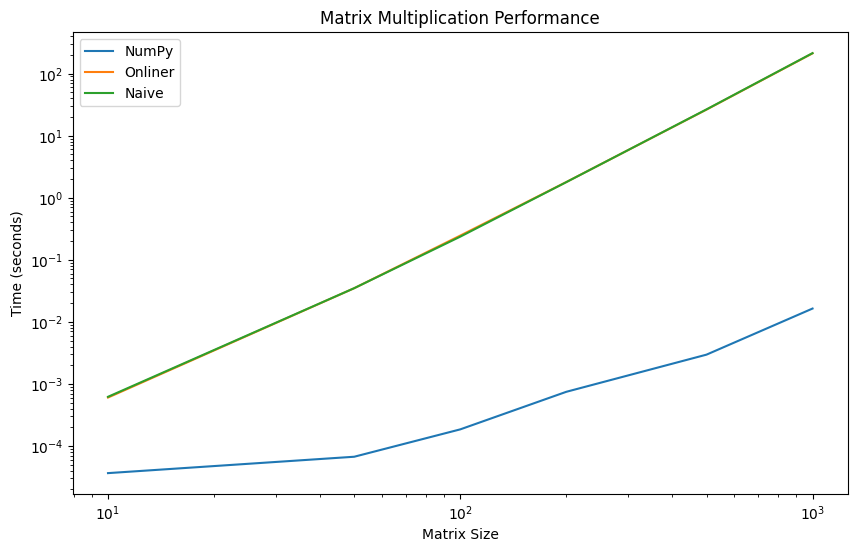

In [9]:
fig, ax = plt.subplots(figsize= (10, 6))
ax.plot(sizes, numpy_times, label='NumPy')
ax.plot(sizes, onliner_times, label='Onliner')
ax.plot(sizes, naive_times, label='Naive')
ax.set_xlabel('Matrix Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('Matrix Multiplication Performance')
ax.legend()
plt.xscale('log')
plt.yscale('log')